In [11]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [12]:
# !pip install pandas-profiling
# !pip install ydata-profiling


In [13]:
from ydata_profiling import ProfileReport

In [14]:
df = pd.read_csv("../dataset/model_ready_dataset.csv")

In [15]:
df.shape

(2260, 29)

In [16]:
df.head()

,Player,Nation,Age,Born,Squad,League,Position,90s,SCA SCA,SCA Types PassLive,...,GCA Types Sh,GCA Types Fld,GCA Types Def,overall_rating,potential,value_num,wage_num,release_clause_num,SCA90,GCA90
0,Aaron Cresswell,ENG,33.0,1989,West Ham,Premier League,Defender,4.8,12,7,...,0,0,0,73,73,1000000.0,57000.0,1900000.0,2.50,0.21
1,Aaron Hickey,SCO,21.0,2002,Brentford,Premier League,Defender,7.9,7,6,...,0,0,0,75,80,8000000.0,47000.0,15800000.0,0.89,0.00
2,Aaron Ramsdale,ENG,25.0,1998,Arsenal,Premier League,Goalkeeper,6.0,0,0,...,0,0,0,78,80,13000000.0,36000.0,27000000.0,0.00,0.00
3,Aaron Ramsey,ENG,20.0,2003,Burnley,Premier League,Midfielder,11.8,10,10,...,0,0,0,73,80,3600000.0,31000.0,7600000.0,0.85,0.00
4,Aaron Seydel,GER,27.0,1996,Darmstadt 98,Bundesliga,Forward,6.9,13,12,...,0,0,0,68,68,1200000.0,11000.0,1500000.0,1.88,0.14


In [17]:
df = df[df['Position'] != 'Goalkeeper'].copy()
df = df[df['value_num'] > 0].copy()
df['Age2'] = df['Age'] ** 2


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2078 entries, 0 to 2257
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Player              2078 non-null   object 
 1   Nation              2074 non-null   object 
 2   Age                 2074 non-null   float64
 3   Born                2078 non-null   int64  
 4   Squad               2078 non-null   object 
 5   League              2078 non-null   object 
 6   Position            2078 non-null   object 
 7   90s                 2078 non-null   float64
 8   SCA SCA             2078 non-null   int64  
 9   SCA Types PassLive  2078 non-null   int64  
 10  SCA Types PassDead  2078 non-null   int64  
 11  SCA Types TO        2078 non-null   int64  
 12  SCA Types Sh        2078 non-null   int64  
 13  SCA Types Fld       2078 non-null   int64  
 14  SCA Types Def       2078 non-null   int64  
 15  GCA GCA             2078 non-null   int64  
 16  GCA Types P

In [19]:
df.describe()

,Age,Born,90s,SCA SCA,SCA Types PassLive,SCA Types PassDead,SCA Types TO,SCA Types Sh,SCA Types Fld,SCA Types Def,...,GCA Types Fld,GCA Types Def,overall_rating,potential,value_num,wage_num,release_clause_num,SCA90,GCA90,Age2
count,2074.000000,2078.000000,2078.000000,2078.000000,2078.000000,2078.000000,2078.000000,2078.000000,2078.000000,2078.000000,...,2078.000000,2078.000000,2078.000000,2078.000000,2.078000e+03,2078.000000,2.078000e+03,2078.000000,2078.000000,2074.000000
mean,24.751688,1994.076997,15.057363,34.669394,25.087584,3.109240,1.962464,2.238210,1.643888,0.628008,...,0.238691,0.059192,73.687680,77.400866,1.129981e+07,39384.023099,1.955283e+07,2.293845,0.241713,631.808582
std,4.378560,87.703169,11.773832,36.881676,25.997056,7.839022,3.416031,2.879466,2.530172,1.078402,...,0.592689,0.272048,5.918004,5.279254,1.717174e+07,39995.338857,3.355837e+07,1.795679,0.434397,223.591410
min,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,53.000000,57.000000,1.300000e+05,1000.000000,0.000000e+00,0.000000,0.000000,225.000000
25%,21.000000,1995.000000,4.900000,8.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,70.000000,74.000000,2.000000e+06,14000.000000,1.800000e+06,1.130000,0.000000,441.000000
50%,25.000000,1998.000000,14.200000,24.000000,18.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,74.000000,78.000000,4.800000e+06,27000.000000,6.800000e+06,2.080000,0.160000,625.000000
75%,28.000000,2001.000000,23.100000,49.000000,36.000000,2.000000,2.750000,3.000000,2.000000,1.000000,...,0.000000,0.000000,78.000000,81.000000,1.350000e+07,49000.000000,2.300000e+07,3.107500,0.330000,784.000000
max,38.000000,2008.000000,141.300000,352.000000,242.000000,82.000000,34.000000,30.000000,27.000000,12.000000,...,6.000000,4.000000,91.000000,95.000000,1.745000e+08,440000.000000,3.708000e+08,30.000000,10.000000,1444.000000


In [20]:
df_numeric = df.drop(['Player', 'Nation', 'Born', 'Squad', 'League', 'Position', 'overall_rating', 'potential', 'wage_num', 'release_clause_num', 'Age'], axis=1)

cols = df_numeric.columns.to_list()
cols.append(cols.pop(cols.index('value_num')))

df_numeric = df_numeric[cols]
df_numeric.head()

,90s,SCA SCA,SCA Types PassLive,SCA Types PassDead,SCA Types TO,SCA Types Sh,SCA Types Fld,SCA Types Def,GCA GCA,GCA Types PassLive,GCA Types PassDead,GCA Types TO,GCA Types Sh,GCA Types Fld,GCA Types Def,SCA90,GCA90,Age2,value_num
0,4.8,12,7,3,0,0,2,0,1,1,0,0,0,0,0,2.50,0.21,1089.0,1000000.0
1,7.9,7,6,0,0,0,1,0,0,0,0,0,0,0,0,0.89,0.00,441.0,8000000.0
3,11.8,10,10,0,0,0,0,0,0,0,0,0,0,0,0,0.85,0.00,400.0,3600000.0
4,6.9,13,12,0,0,0,1,0,1,1,0,0,0,0,0,1.88,0.14,729.0,1200000.0
5,19.8,26,24,1,0,0,1,0,3,3,0,0,0,0,0,1.31,0.15,625.0,22500000.0


In [21]:
df_numeric.isna().any()

90s                   False
SCA SCA               False
SCA Types PassLive    False
SCA Types PassDead    False
SCA Types TO          False
SCA Types Sh          False
SCA Types Fld         False
SCA Types Def         False
GCA GCA               False
GCA Types PassLive    False
GCA Types PassDead    False
GCA Types TO          False
GCA Types Sh          False
GCA Types Fld         False
GCA Types Def         False
SCA90                 False
GCA90                 False
Age2                   True
value_num             False
dtype: bool

In [22]:
df_numeric.isna().sum()

90s                   0
SCA SCA               0
SCA Types PassLive    0
SCA Types PassDead    0
SCA Types TO          0
SCA Types Sh          0
SCA Types Fld         0
SCA Types Def         0
GCA GCA               0
GCA Types PassLive    0
GCA Types PassDead    0
GCA Types TO          0
GCA Types Sh          0
GCA Types Fld         0
GCA Types Def         0
SCA90                 0
GCA90                 0
Age2                  4
value_num             0
dtype: int64

In [23]:
df_numeric = df_numeric.dropna()

In [24]:
df_numeric.corr()
corr_matrix = df_numeric.corr()
corr_matrix['value_num'].sort_values(ascending=False)

value_num             1.000000
GCA GCA               0.531333
GCA Types PassLive    0.510924
SCA Types PassLive    0.481276
SCA SCA               0.472396
SCA Types TO          0.408557
SCA Types Sh          0.369908
GCA Types TO          0.347442
90s                   0.339905
SCA Types Fld         0.310914
GCA Types Sh          0.277560
GCA Types Fld         0.254272
SCA Types Def         0.215198
SCA90                 0.191499
SCA Types PassDead    0.182362
GCA Types Def         0.166563
GCA Types PassDead    0.158378
GCA90                 0.158058
Age2                 -0.070565
Name: value_num, dtype: float64

In [25]:
df_numeric = df_numeric[['value_num', 'GCA GCA', 'SCA Types PassLive', 'GCA Types PassLive', 'SCA SCA', 'SCA Types TO', 'SCA Types Sh', 'GCA Types TO', '90s', 'Age2']]

In [26]:
df_numeric.corr()

,value_num,GCA GCA,SCA Types PassLive,GCA Types PassLive,SCA SCA,SCA Types TO,SCA Types Sh,GCA Types TO,90s,Age2
value_num,1.000000,0.531333,0.481276,0.510924,0.472396,0.408557,0.369908,0.347442,0.339905,-0.070565
GCA GCA,0.531333,1.000000,0.851142,0.947293,0.870090,0.642414,0.655023,0.575894,0.622623,0.109975
SCA Types PassLive,0.481276,0.851142,1.000000,0.844793,0.974549,0.610848,0.650511,0.395276,0.758839,0.170647
GCA Types PassLive,0.510924,0.947293,0.844793,1.000000,0.824369,0.561201,0.568312,0.440477,0.618730,0.118099
SCA SCA,0.472396,0.870090,0.974549,0.824369,1.000000,0.677531,0.704386,0.438177,0.732185,0.157911
SCA Types TO,0.408557,0.642414,0.610848,0.561201,0.677531,1.000000,0.603330,0.661091,0.388062,-0.056692
SCA Types Sh,0.369908,0.655023,0.650511,0.568312,0.704386,0.603330,1.000000,0.395791,0.555738,0.120303
GCA Types TO,0.347442,0.575894,0.395276,0.440477,0.438177,0.661091,0.395791,1.000000,0.232773,-0.038475
90s,0.339905,0.622623,0.758839,0.618730,0.732185,0.388062,0.555738,0.232773,1.000000,0.248100
Age2,-0.070565,0.109975,0.170647,0.118099,0.157911,-0.056692,0.120303,-0.038475,0.248100,1.000000


In [27]:
# profile = ProfileReport(df,title="GoalMinder")
# profile.to_notebook_iframe()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [29]:
base_features = ['GCA GCA', 'GCA Types PassLive', 'SCA SCA', 'SCA Types TO', 'SCA Types Sh', '90s', 'Age2']

In [30]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [31]:
import numpy as np

players = df['Player'].unique()
train_players, test_players = train_test_split(
    players, test_size=0.2, random_state=42
)

train_df = df[df['Player'].isin(train_players)]
test_df  = df[df['Player'].isin(test_players)]

X_train = train_df[base_features].fillna(0)
X_test  = test_df[base_features].fillna(0)


y_train = np.log1p(train_df['value_num'])
y_test  = np.log1p(test_df['value_num'])

scaler = StandardScaler()
X_train_scaled_svm = scaler.fit_transform(X_train)
X_test_scaled_svm =  scaler.transform(X_test)

In [32]:
rf_model = RandomForestRegressor(
    n_estimators   = 500,
    max_depth      = 8,
    min_samples_leaf = 5,
    random_state   = 42,
    n_jobs         = -1
)
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [33]:
y_pred = rf_model.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)


MAE: 0.7815911824619515


In [35]:
import shap

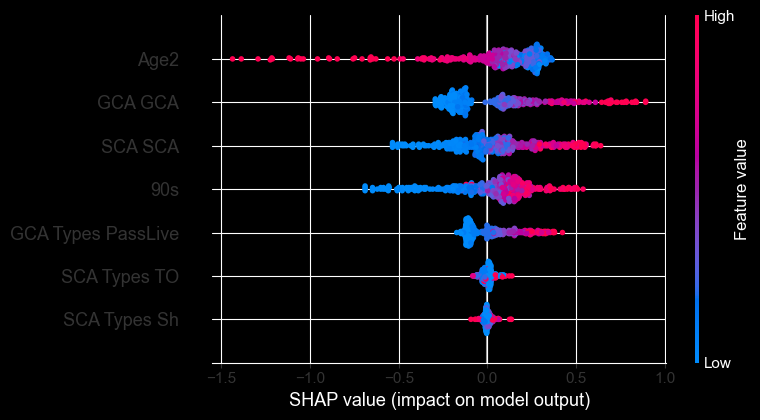

In [36]:
explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [37]:
gb_model = GradientBoostingRegressor(
    n_estimators    = 500,
    learning_rate   = 0.05,
    max_depth       = 4,
    subsample       = 0.8,
    min_samples_leaf= 10,
    random_state    = 42
)
gb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

In [38]:
y_pred = gb_model.predict(X_test)

In [39]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.8295271978651437


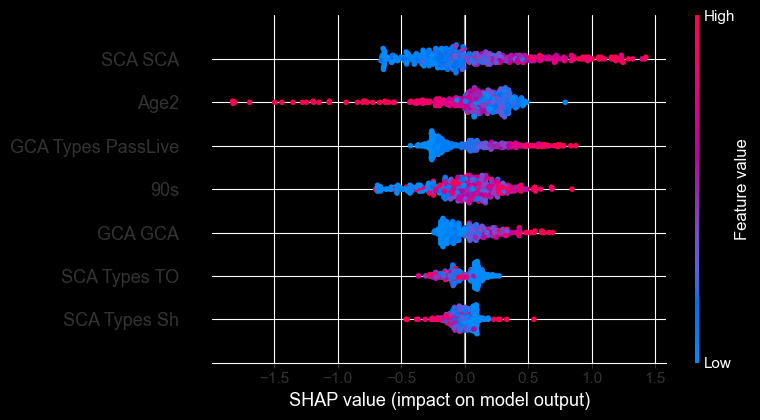

In [40]:
explainer = shap.Explainer(gb_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [41]:
xb_model = XGBRegressor(
    n_estimators    = 500,
    learning_rate   = 0.05,
    max_depth       = 4,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    n_jobs          = -1,
    verbosity       = 0
)
xb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [42]:
y_pred = xb_model.predict(X_test)


In [43]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.8227579268978217


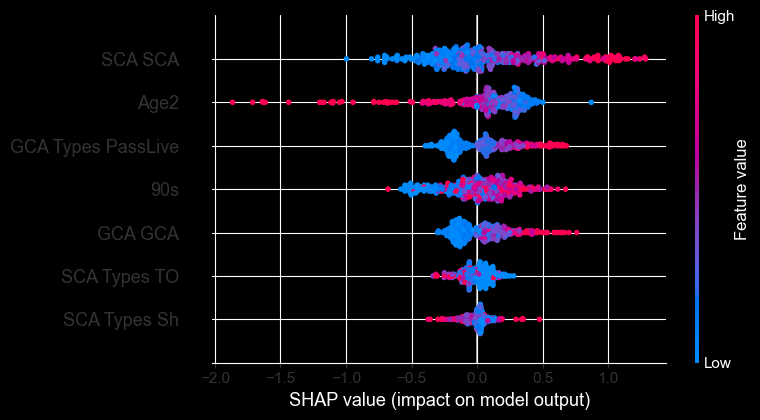

In [44]:
explainer = shap.Explainer(xb_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [45]:
svr_model = SVR()

svr_model.fit(X_train_scaled_svm, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [46]:
y_pred = svr_model.predict(X_test_scaled_svm)

In [47]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.7675179694177576


In [48]:
# model expects     ← original column
# 'GCA GCA'        ← 'GCA'
# 'SCA SCA'        ← 'SCA'
# 'GCA Types PassLive' ← 'PassLive'  (GCA subtype)
# 'SCA Types TO'   ← 'TO'
# 'SCA Types Sh'   ← 'Sh'
# '90s'            ← '90s'  ✓ exact match
# 'Age2'           ← computed from 'Age'

In [49]:
main_df = pd.read_csv('../dataset/career_player_dataset_cleaned.csv')

In [50]:
pred_features = ['GCA', 'PassLive', 'SCA', 'TO', 'Sh', '90s', 'Age']

In [51]:
pred_features_df = main_df[pred_features].copy()

In [52]:
pred_features_df['Age'] = pred_features_df['Age'] ** 2

In [53]:
pred_features_df.isna().sum()

GCA         0
PassLive    0
SCA         0
TO          0
Sh          0
90s         0
Age         0
dtype: int64

In [54]:
pred_features_df.columns = base_features
predictions = rf_model.predict(pred_features_df)

main_df['Value'] = np.expm1(predictions)

In [55]:
main_df.head()

,player_name,Season,Age,MP,Starts,Min,90s,Goals,Assists,GoalsandAssists,...,TouchesLive,TouchesMid 3rd,League,Team,Player,Nation,Pos,season,Total_Seasons_Played,Value
0,aaroncresswell,0.0,33.0,157.0,203.0,18187.0,202.0,6.0,17.0,23.0,...,13507.0,6172.0,EPL,west ham,aaron cresswell,eng ENG,"DF / DF,FW",2017-2018 / 2018-2019 / 2019-2020 / 2020-2021 ...,7,1.079595e+07
1,aaronescandell,0.0,27.0,14.0,12.0,1157.0,12.9,0.0,0.0,0.0,...,532.0,3.0,LaLiga,las palmas,aaron escandell,es ESP,GK,2017-2018 / 2018-2019 / 2019-2020 / 2020-2021 ...,6,4.847106e+06
2,aaronhickey,0.0,21.0,82.0,99.0,8123.0,90.2,5.0,3.0,8.0,...,4509.0,2059.0,SeriaA / EPL,brentford,aaron hickey,sct SCO,DF,2017-2018 / 2018-2019 / 2019-2020 / 2020-2021 ...,7,1.024335e+07
3,aaronmalouda,0.0,17.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,Ligue1,lille,aaron malouda,fr FRA,FW,2023-2024,1,1.267684e+06
4,aaronmartin,0.0,26.0,161.0,186.0,16649.0,185.0,11.0,14.0,25.0,...,10445.0,4533.0,LaLiga / Bundesliga / Bundesliga / LaLiga / Se...,genoa,aaron martin,es ESP,"DF / DF,FW / DF",2017-2018 / 2018-2019 / 2019-2020 / 2020-2021 ...,7,2.596707e+07


In [56]:
main_df.drop('Season', axis=1, inplace=True)

In [57]:
main_df.isna().sum().sort_values(ascending=True)

player_name         0
Matches             0
L                   0
GA90                0
GA                  0
                   ..
Total_Blocks        0
Tackles_mid_3rd     0
PrgDist             0
Value               0
Nation             11
Length: 120, dtype: int64

In [58]:
numeric_features = [
    'Goals', 'Assists', 'GoalsandAssists', 'NonPenaltyGoals', 'PenaltyGoals',
    'PenaltiesAttemped', 'GoalsPer90', 'AssistPer90', 'GoalsandAssistPer90',
    'NonPenaltyGoalsPer90', 'Shots', 'ShotsOnTarget', 'Sh/90', 'GoalsPerShot',
    'GoalsPerShotOnTarget', 'AvgShotDistance',

    'PrgC', 'ProgressiveCarries', 'ProgressivePasses', 'PrgDist',
    'Att', 'Cmp', 'Cmp%', 'LP_Att', 'LP_Cmp', 'LP_Cmp%', 'MP_Att', 'MP_Cmp',
    'MP_Cmp%', 'SP_Att', 'SP_Cmp', 'SP_Cmp%', 'Passes_Att', 'PassDead', 'PassLive',

    'Clearance', 'Tackles_Won', 'Tackles_Att_3rd', 'Tackles_Def_3rd',
    'Tackles_mid_3rd', 'Interceptions', 'Drib_Tackled', 'Passes_Blocked',
    'Shots_Blocked', 'Total_Tackles', 'Total_Blocks', 'Drib_Tackle_Lost',
    'Def', 'GA', 'GA90', 'CS', 'CS%',

    'Carries', 'CarriesPenArea', 'ProgressiveFinalThird', 'ProgressiveReceive',
    'ProgressivegDist', 'Touches', 'TouchesAtt 3rd', 'TouchesAtt Pen',
    'TouchesDef 3rd', 'TouchesDef Pen', 'TouchesLive', 'TouchesMid 3rd',
    'DribblesAtt', 'DribbleSucc', 'DribbleSucc%', 'DribbleTkld', 'Miscontrolled',
]

main_df_numeric = main_df[numeric_features + ['Team', 'player_name', 'Value']]

In [59]:
team_name = 'manchester city'
team_players = main_df_numeric[main_df_numeric['Team'] == team_name].copy()

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
player_stats_scaled = pd.DataFrame(
    scaler.fit_transform(team_players[numeric_features]),
    index=team_players.index,
    columns=numeric_features
)


print(player_stats_scaled.head(200))

         Goals   Assists  GoalsandAssists  NonPenaltyGoals  PenaltyGoals  \
358  -0.378467 -0.484594        -0.466793        -0.372463     -0.351826   
597   0.010586 -0.075718        -0.024713        -0.208829      1.062962   
888   3.873334  1.014619         3.108295         3.685670      4.206936   
1269  0.232903  0.878327         0.532694         0.347528     -0.351826   
1301 -0.517415 -0.530025        -0.582119        -0.568824     -0.194627   
1460 -0.322888 -0.484594        -0.428352        -0.307009     -0.351826   
1549 -0.378467 -0.530025        -0.486014        -0.372463     -0.351826   
1573  0.205113 -0.302871         0.013729         0.183894      0.276969   
1615 -0.572994 -0.530025        -0.620561        -0.601551     -0.351826   
1649  1.122168  3.876754         2.416343         1.263881      0.276969   
1719 -0.517415  0.151436        -0.293805        -0.536097     -0.351826   
1907 -0.434046 -0.530025        -0.524456        -0.437917     -0.351826   
2019 -0.4340

In [61]:
from sklearn.cluster import KMeans

n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(player_stats_scaled)

team_players['Cluster'] = clusters

print(team_players[['player_name', 'Cluster']])

cluster_summary = team_players.groupby('Cluster')[numeric_features].mean()
print(cluster_summary)

         player_name  Cluster
358   aymericlaporte        3
597       colepalmer        0
888    erlinghaaland        0
1269    jackgrealish        2
1301     jamesmcatee        0
1460      johnstones        3
1549   joskogvardiol        3
1573   julianalvarez        0
1615  kalvinphillips        0
1649   kevindebruyne        2
1719      kylewalker        1
1907    manuelakanji        3
2019    mateokovacic        1
2028    matheusnunes        1
2272       nathanake        3
2413       oscarbobb        0
2511       philfoden        2
2631       ricolewis        0
2690       rubendias        3
2801     sergiogomez        0
2872    stefanortega        0
             Goals    Assists  GoalsandAssists  NonPenaltyGoals  PenaltyGoals  \
Cluster                                                                         
0        24.333333   7.777778        32.111111        19.555556      4.777778   
1         6.333333  14.333333        20.666667         6.333333      0.000000   
2        52.3333

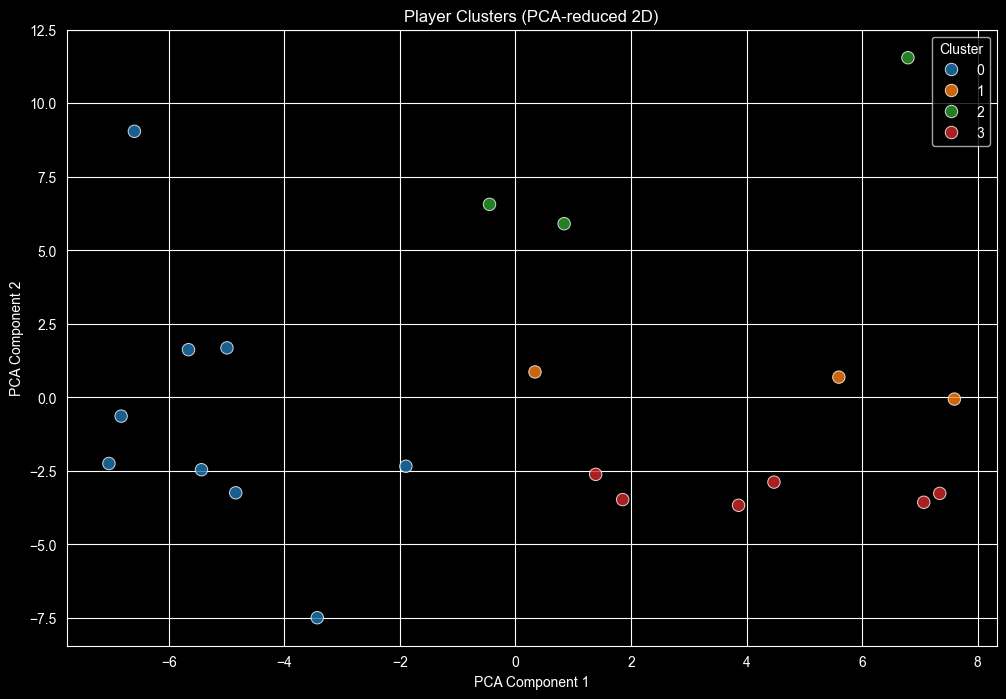

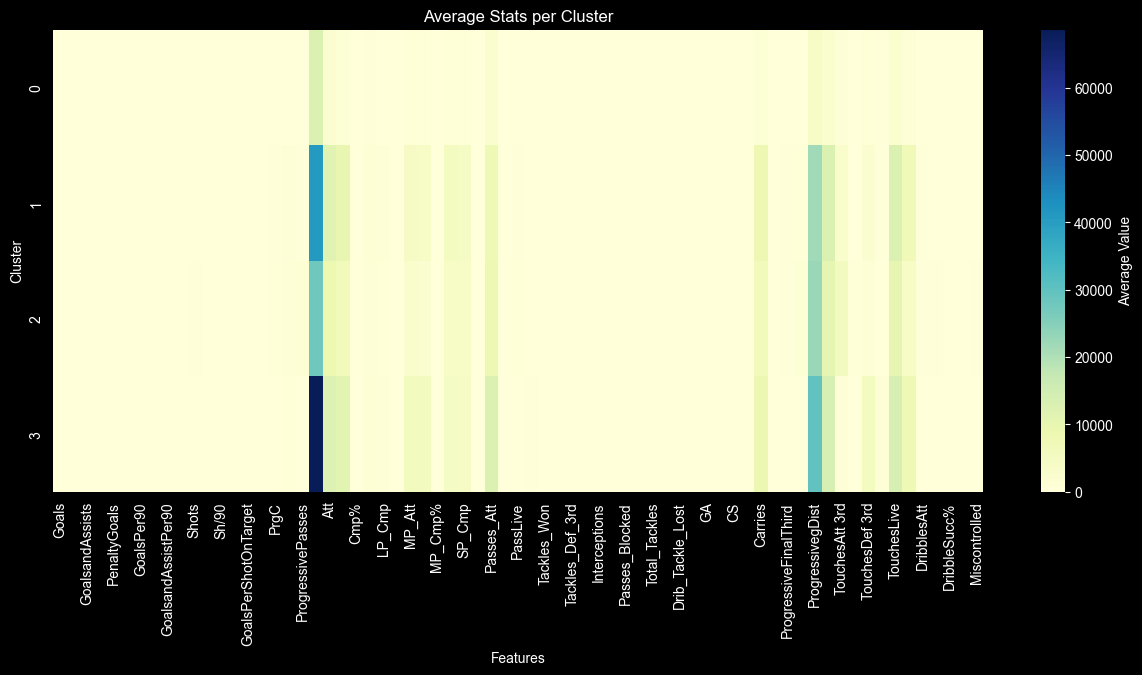


--- Top 5 Players in Cluster 0 ---


,Goals,Assists,GoalsandAssists,NonPenaltyGoals,PenaltyGoals,PenaltiesAttemped,GoalsPer90,AssistPer90,GoalsandAssistPer90,NonPenaltyGoalsPer90,...,TouchesMid 3rd,DribblesAtt,DribbleSucc,DribbleSucc%,DribbleTkld,Miscontrolled,Team,player_name,Value,Cluster
888,161.0,37.0,198.0,132.0,29.0,32.0,1.08,0.25,1.32,0.88,...,1510.0,188.0,89.0,47.34,90.0,279.0,manchester city,erlinghaaland,3.469445e+07,0
1573,29.0,8.0,37.0,25.0,4.0,4.0,0.47,0.13,0.60,0.40,...,983.0,118.0,62.0,52.54,50.0,112.0,manchester city,julianalvarez,3.522352e+07,0
597,22.0,13.0,35.0,13.0,9.0,9.0,0.57,0.34,0.90,0.34,...,944.0,156.0,81.0,51.92,61.0,91.0,manchester city,colepalmer,4.680270e+07,0
1301,3.0,3.0,6.0,2.0,1.0,1.0,0.15,0.15,0.29,0.10,...,325.0,93.0,34.0,36.56,52.0,50.0,manchester city,jamesmcatee,1.339491e+07,0
2631,2.0,0.0,2.0,2.0,0.0,0.0,0.07,0.00,0.07,0.07,...,1119.0,37.0,20.0,54.05,10.0,16.0,manchester city,ricolewis,1.196057e+07,0



--- Top 5 Players in Cluster 1 ---


,Goals,Assists,GoalsandAssists,NonPenaltyGoals,PenaltyGoals,PenaltiesAttemped,GoalsPer90,AssistPer90,GoalsandAssistPer90,NonPenaltyGoalsPer90,...,TouchesMid 3rd,DribblesAtt,DribbleSucc,DribbleSucc%,DribbleTkld,Miscontrolled,Team,player_name,Value,Cluster
2028,10.0,9.0,19.0,10.0,0.0,0.0,0.08,0.08,0.16,0.08,...,3581.0,401.0,251.0,62.59,121.0,222.0,manchester city,matheusnunes,3.607674e+07,1
2019,6.0,16.0,22.0,6.0,0.0,0.0,0.04,0.11,0.15,0.04,...,7973.0,400.0,303.0,75.75,82.0,187.0,manchester city,mateokovacic,1.837945e+07,1
1719,3.0,18.0,21.0,3.0,0.0,0.0,0.01,0.09,0.10,0.01,...,10889.0,231.0,145.0,62.77,79.0,162.0,manchester city,kylewalker,1.302075e+07,1



--- Top 5 Players in Cluster 2 ---


,Goals,Assists,GoalsandAssists,NonPenaltyGoals,PenaltyGoals,PenaltiesAttemped,GoalsPer90,AssistPer90,GoalsandAssistPer90,NonPenaltyGoalsPer90,...,TouchesMid 3rd,DribblesAtt,DribbleSucc,DribbleSucc%,DribbleTkld,Miscontrolled,Team,player_name,Value,Cluster
2511,65.0,33.0,98.0,65.0,0.0,0.0,0.51,0.26,0.76,0.51,...,2847.0,433.0,238.0,54.97,166.0,250.0,manchester city,philfoden,3.469445e+07,2
1649,62.0,100.0,162.0,58.0,4.0,5.0,0.33,0.53,0.85,0.31,...,6276.0,472.0,283.0,59.96,166.0,316.0,manchester city,kevindebruyne,1.260756e+07,2
1269,30.0,34.0,64.0,30.0,0.0,1.0,0.22,0.25,0.46,0.22,...,2670.0,547.0,286.0,52.29,175.0,248.0,manchester city,jackgrealish,2.180596e+07,2



--- Top 5 Players in Cluster 3 ---


,Goals,Assists,GoalsandAssists,NonPenaltyGoals,PenaltyGoals,PenaltiesAttemped,GoalsPer90,AssistPer90,GoalsandAssistPer90,NonPenaltyGoalsPer90,...,TouchesMid 3rd,DribblesAtt,DribbleSucc,DribbleSucc%,DribbleTkld,Miscontrolled,Team,player_name,Value,Cluster
2272,15.0,7.0,22.0,15.0,0.0,0.0,0.08,0.04,0.12,0.08,...,6542.0,42.0,27.0,64.29,11.0,85.0,manchester city,nathanake,9.956023e+06,3
2690,12.0,7.0,19.0,12.0,0.0,0.0,0.05,0.03,0.09,0.05,...,10175.0,50.0,33.0,66.00,15.0,52.0,manchester city,rubendias,1.688993e+07,3
1460,10.0,4.0,14.0,10.0,0.0,0.0,0.08,0.03,0.11,0.08,...,6705.0,63.0,46.0,73.02,10.0,39.0,manchester city,johnstones,9.466859e+06,3
358,8.0,4.0,12.0,8.0,0.0,0.0,0.06,0.03,0.08,0.06,...,7963.0,36.0,24.0,66.67,10.0,40.0,manchester city,aymericlaporte,1.020397e+07,3
1549,8.0,3.0,11.0,8.0,0.0,0.0,0.08,0.03,0.11,0.08,...,4826.0,130.0,95.0,73.08,30.0,69.0,manchester city,joskogvardiol,1.675428e+07,3


In [62]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_features = [
    'Goals', 'Assists', 'GoalsandAssists', 'NonPenaltyGoals', 'PenaltyGoals',
    'PenaltiesAttemped', 'GoalsPer90', 'AssistPer90', 'GoalsandAssistPer90',
    'NonPenaltyGoalsPer90', 'Shots', 'ShotsOnTarget', 'Sh/90', 'GoalsPerShot',
    'GoalsPerShotOnTarget', 'AvgShotDistance',
    'PrgC', 'ProgressiveCarries', 'ProgressivePasses', 'PrgDist',
    'Att', 'Cmp', 'Cmp%', 'LP_Att', 'LP_Cmp', 'LP_Cmp%', 'MP_Att', 'MP_Cmp',
    'MP_Cmp%', 'SP_Att', 'SP_Cmp', 'SP_Cmp%', 'Passes_Att', 'PassDead', 'PassLive',
    'Clearance', 'Tackles_Won', 'Tackles_Att_3rd', 'Tackles_Def_3rd',
    'Tackles_mid_3rd', 'Interceptions', 'Drib_Tackled', 'Passes_Blocked',
    'Shots_Blocked', 'Total_Tackles', 'Total_Blocks', 'Drib_Tackle_Lost',
    'Def', 'GA', 'GA90', 'CS', 'CS%',
    'Carries', 'CarriesPenArea', 'ProgressiveFinalThird', 'ProgressiveReceive',
    'ProgressivegDist', 'Touches', 'TouchesAtt 3rd', 'TouchesAtt Pen',
    'TouchesDef 3rd', 'TouchesDef Pen', 'TouchesLive', 'TouchesMid 3rd',
    'DribblesAtt', 'DribbleSucc', 'DribbleSucc%', 'DribbleTkld', 'Miscontrolled',
]

scaler = StandardScaler()
player_stats_scaled = pd.DataFrame(
    scaler.fit_transform(team_players[numeric_features]),
    index=team_players.index,
    columns=numeric_features
)

pca = PCA(n_components=2)
player_pca = pca.fit_transform(player_stats_scaled)

plt.figure(figsize=(12,8))
sns.scatterplot(
    x=player_pca[:,0],
    y=player_pca[:,1],
    hue=team_players['Cluster'],
    palette='tab10',
    s=80,
    alpha=0.8
)
plt.title("Player Clusters (PCA-reduced 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

cluster_summary = team_players.groupby('Cluster')[numeric_features].mean()

plt.figure(figsize=(15,6))
sns.heatmap(cluster_summary, cmap="YlGnBu", cbar_kws={'label': 'Average Value'})
plt.title("Average Stats per Cluster")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()

for cluster in sorted(team_players['Cluster'].unique()):
    print(f"\n--- Top 5 Players in Cluster {cluster} ---")
    top_players = team_players[team_players['Cluster'] == cluster] \
                    .sort_values(by=['Goals', 'Assists'], ascending=False) \
                    .head(5)
    display(top_players)

In [63]:
from sklearn.cluster import DBSCAN

player_stats_scaled = pd.DataFrame(
    scaler.fit_transform(main_df_numeric[numeric_features]),
    index=main_df_numeric.index,
    columns=numeric_features
)


dbscan = DBSCAN(eps=2.5, min_samples=3)
clusters = dbscan.fit_predict(player_stats_scaled)

cluster_df = main_df_numeric.copy()

cluster_df['Cluster'] = clusters

display(cluster_df[['player_name', 'Team', 'Cluster']].head(10))
cluster_summary = cluster_df.groupby('Cluster')[numeric_features].mean()
display(cluster_summary)

,player_name,Team,Cluster
0,aaroncresswell,west ham,-1
1,aaronescandell,las palmas,0
2,aaronhickey,brentford,1
3,aaronmalouda,lille,2
4,aaronmartin,genoa,-1
5,aaronmeijers,rkc waalwijk,-1
6,aaronramsdale,arsenal,3
7,aaronramsey,burnley,-1
8,aaronseydel,darmstadt 98,1
9,aaronwan-bissaka,manchester utd,-1


,Goals,Assists,GoalsandAssists,NonPenaltyGoals,PenaltyGoals,PenaltiesAttemped,GoalsPer90,AssistPer90,GoalsandAssistPer90,NonPenaltyGoalsPer90,...,TouchesAtt Pen,TouchesDef 3rd,TouchesDef Pen,TouchesLive,TouchesMid 3rd,DribblesAtt,DribbleSucc,DribbleSucc%,DribbleTkld,Miscontrolled
Cluster,,,,,,,,,,,,,,,,,,,,,
-1,21.845674,15.295272,37.140946,19.545049,2.300624,2.842105,0.187360,0.154996,0.342114,0.170847,...,304.803747,2226.306869,639.434434,8003.369313,3794.023194,236.768956,125.625335,54.102551,99.698483,201.429973
0,0.000000,0.135417,0.135417,0.000000,0.000000,0.000000,0.000000,0.006771,0.006771,0.000000,...,0.135417,1416.291667,1191.562500,1426.687500,10.677083,0.052083,0.020833,0.520833,0.031250,1.197917
1,3.965110,2.841868,6.806978,3.828362,0.136747,0.201463,0.102330,0.073545,0.175768,0.098846,...,70.452448,666.633652,145.289252,2063.885200,964.619584,62.906021,30.761396,46.913376,27.541362,56.135059
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.062500,0.562500,0.343750,1.343750,0.375000,0.093750,0.000000,0.000000,0.062500,0.125000
3,0.000000,0.223881,0.223881,0.000000,0.000000,0.000000,0.000000,0.002537,0.002537,0.000000,...,0.283582,3325.417910,2766.641791,3357.880597,33.537313,3.089552,3.000000,97.956716,0.089552,2.626866
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.250000,0.250000,3.750000,2.000000,0.250000,0.000000,0.000000,0.250000,0.000000
5,0.000000,0.700000,0.700000,0.000000,0.000000,0.000000,0.000000,0.004000,0.004000,0.000000,...,0.700000,7572.600000,6331.600000,7649.200000,78.700000,0.500000,0.100000,2.000000,0.400000,4.600000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.275862,1.448276,0.344828,6.413793,3.000000,0.448276,0.000000,0.000000,0.413793,0.620690
7,4.666667,3.333333,8.000000,4.666667,0.000000,0.000000,0.033333,0.023333,0.053333,0.033333,...,101.000000,5238.333333,1152.666667,11311.000000,5623.666667,42.666667,32.333333,76.993333,9.666667,62.333333


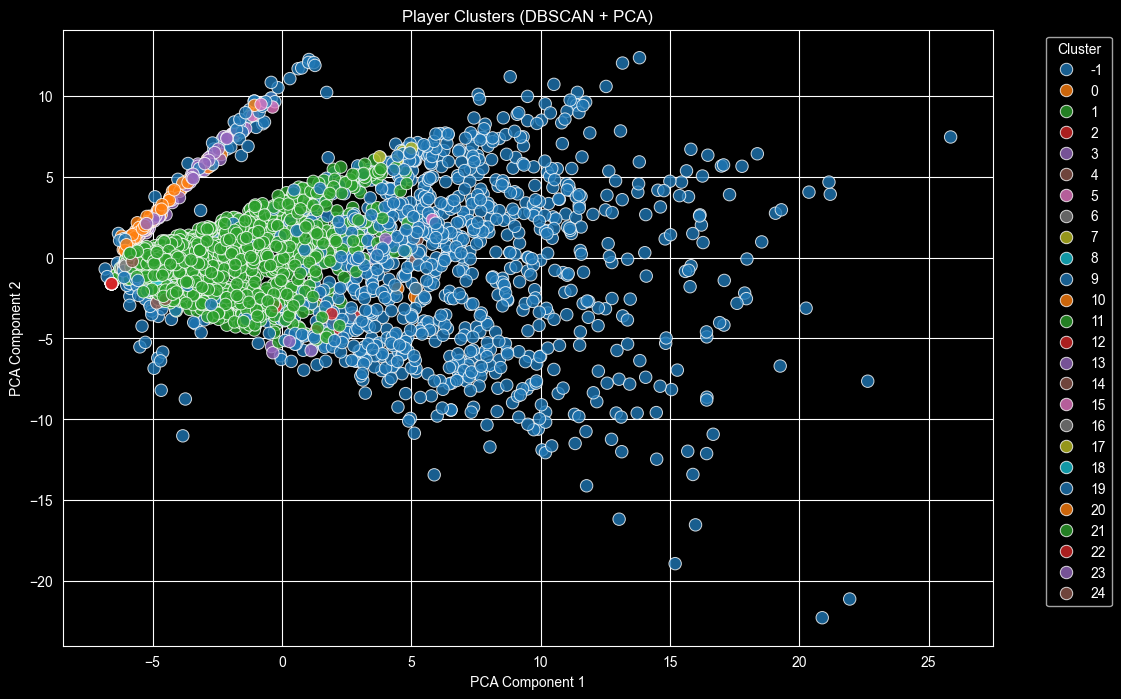

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
player_pca = pca.fit_transform(player_stats_scaled)

plt.figure(figsize=(12,8))
sns.scatterplot(
    x=player_pca[:,0],
    y=player_pca[:,1],
    hue=cluster_df['Cluster'],
    palette='tab10',
    s=80,
    alpha=0.8
)
plt.title("Player Clusters (DBSCAN + PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [68]:
from sklearn.neighbors import NearestNeighbors

X = player_stats_scaled.values
knn = NearestNeighbors(n_neighbors=11, metric='euclidean')
knn.fit(X)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [72]:
player_name = "harrykane"
player_index = cluster_df[cluster_df['player_name'] == player_name].index[0]

distances, indices = knn.kneighbors([X[player_index]])
similar_players = cluster_df.iloc[indices[0]].copy()
similar_players['Distance'] = distances[0]

display(similar_players.sort_values('Distance'))

,Goals,Assists,GoalsandAssists,NonPenaltyGoals,PenaltyGoals,PenaltiesAttemped,GoalsPer90,AssistPer90,GoalsandAssistPer90,NonPenaltyGoalsPer90,...,DribblesAtt,DribbleSucc,DribbleSucc%,DribbleTkld,Miscontrolled,Team,player_name,Value,Cluster,Distance
1141,201.0,45.0,246.0,170.0,31.0,34.0,0.75,0.17,0.92,0.64,...,708.0,325.0,45.90,347.0,565.0,bayern munich,harrykane,1.363572e+07,-1,3.371748e-07
2640,226.0,45.0,271.0,195.0,31.0,36.0,0.94,0.19,1.12,0.81,...,526.0,280.0,53.23,238.0,643.0,barcelona,robertlewandowski,1.215718e+07,-1,5.318809e+00
3119,144.0,42.0,186.0,110.0,34.0,38.0,0.71,0.21,0.91,0.54,...,431.0,214.0,49.65,209.0,410.0,monaco,wissambenyedder,1.260756e+07,-1,9.236182e+00
129,127.0,37.0,164.0,106.0,21.0,26.0,0.62,0.18,0.80,0.52,...,424.0,242.0,57.08,159.0,463.0,lyon,alexandrelacazette,1.260756e+07,-1,1.088656e+01
1177,121.0,48.0,169.0,94.0,27.0,36.0,0.48,0.19,0.67,0.37,...,550.0,314.0,57.09,212.0,454.0,celta vigo,iagoaspas,1.213756e+07,-1,1.111865e+01
590,158.0,40.0,198.0,110.0,48.0,58.0,0.70,0.18,0.87,0.49,...,385.0,169.0,43.90,204.0,583.0,lazio,ciroimmobile,1.216846e+07,-1,1.136369e+01
1735,124.0,29.0,153.0,112.0,12.0,19.0,0.68,0.16,0.84,0.61,...,449.0,186.0,41.43,229.0,531.0,inter,lautaromartinez,2.460456e+07,-1,1.176482e+01
228,107.0,40.0,147.0,80.0,27.0,32.0,0.53,0.20,0.73,0.40,...,413.0,207.0,50.12,186.0,398.0,hoffenheim,andrejkramaric,1.260756e+07,-1,1.196206e+01
888,161.0,37.0,198.0,132.0,29.0,32.0,1.08,0.25,1.32,0.88,...,188.0,89.0,47.34,90.0,279.0,manchester city,erlinghaaland,3.469445e+07,-1,1.248976e+01
1049,98.0,29.0,127.0,81.0,17.0,24.0,0.52,0.15,0.67,0.43,...,641.0,366.0,57.10,258.0,492.0,villarreal,gerardmoreno,1.255671e+07,-1,1.256549e+01
